# Influenza Outbreak Detection using Machine Learning

## Problem Overview
Influenza surveillance systems collect weekly reports of respiratory virus activity from laboratories and healthcare institutions worldwide. Detecting unusually high levels of influenza activity is essential for early outbreak detection and public health response.

This project applies traditional machine learning techniques to identify influenza outbreak periods using surveillance indicators.

## Objective
The goal of this analysis is to develop a supervised machine learning model to classify influenza activity into:

- **Baseline activity (0)**
- **Outbreak activity (1)**

## Machine Learning Approach
Two machine learning algorithms are evaluated:

- **Logistic Regression** – a linear baseline classifier
- **Random Forest** – a non-linear ensemble classifier

The models are trained on influenza surveillance data and evaluated using performance metrics including accuracy, precision, recall, F1-score and ROC-AUC.

This notebook follows the structure required by the assignment:

1. Data Import
2. Data Description and Exploration
3. Machine Learning Modelling
4. Model Evaluation

## Question 1 – Data Import

The first step is to import the required Python libraries for data analysis, visualisation and machine learning.

The following libraries are used:

- **Pandas** – data manipulation
- **NumPy** – numerical operations
- **Matplotlib / Seaborn** – data visualisation
- **Scikit-learn** – machine learning models and evaluation

In [35]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

In [36]:
# Load influenza surveillance dataset
url = "https://raw.githubusercontent.com/killianharnett1/influenza-outbreak-ml/main/VIW_FNT.csv"

data = pd.read_csv(url, low_memory=False)

display(data.head())

data.info()

,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHERRESPVIRUS,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV
0,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-02,2017,1,2017-01-01,...,NaN,NaN,NaN,NaN,AW,201701,201701,NaN,NaN,NaN
1,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-09,2017,2,2017-01-08,...,NaN,NaN,NaN,NaN,AW,201702,201702,NaN,NaN,NaN
2,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-16,2017,3,2017-01-15,...,NaN,NaN,NaN,NaN,AW,201703,201703,NaN,NaN,NaN
3,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-23,2017,4,2017-01-22,...,NaN,NaN,NaN,NaN,AW,201704,201704,NaN,NaN,NaN
4,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-30,2017,5,2017-01-29,...,NaN,NaN,NaN,NaN,AW,201705,201705,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 181641 entries, 0 to 181640
Data columns (total 53 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   WHOREGION                181641 non-null  str    
 1   FLUSEASON                181641 non-null  str    
 2   HEMISPHERE               181641 non-null  str    
 3   ITZ                      181641 non-null  str    
 4   COUNTRY_CODE             181641 non-null  str    
 5   COUNTRY_AREA_TERRITORY   181641 non-null  str    
 6   ISO_WEEKSTARTDATE        181641 non-null  str    
 7   ISO_YEAR                 181641 non-null  int64  
 8   ISO_WEEK                 181641 non-null  int64  
 9   MMWR_WEEKSTARTDATE       181641 non-null  str    
 10  MMWR_YEAR                181641 non-null  int64  
 11  MMWR_WEEK                181641 non-null  int64  
 12  ORIGIN_SOURCE            181641 non-null  str    
 13  SPEC_PROCESSED_NB        168955 non-null  float64
 14  SPEC_RECEIVED_N

## Data Cleaning and Preparation

Before performing analysis the dataset must be examined for quality issues such as:

- Constant features (columns with only one value)
- Missing values
- Sparse variables

Columns with extremely high missingness are removed because they can introduce noise or instability into machine learning models.

In [37]:
# Calculate number of unique values in each column
# Columns with only one unique value contain no useful information for modelling
nunique = data.nunique(dropna=False)

# Identify constant columns
const_cols = nunique[nunique <= 1].index.tolist()

print("Number of constant columns removed:", len(const_cols))

# Remove constant columns from dataset
data = data.drop(columns=const_cols)

print("Dataset shape after removing constant columns:", data.shape)

Number of constant columns removed: 0
Dataset shape after removing constant columns: (181641, 53)


In [38]:
# Calculate percentage of missing values for each column
missing_pct = data.isna().mean().sort_values(ascending=False)

# Display columns with the highest missingness
display(missing_pct.head(15))


# Identify columns with more than 50% missing values
# These columns are too sparse for reliable modelling
to_drop = missing_pct[missing_pct > 0.50].index.tolist()

print("Columns dropped due to high missingness:", len(to_drop))

# Remove sparse columns
data = data.drop(columns=to_drop)

print("Dataset shape after removing sparse columns:", data.shape)

LAB_RESULT_COMMENT         0.973007
AOTHER_SUBTYPE_DETAILS     0.958792
BVIC_3DEL                  0.949769
BVIC_DELUNK                0.947567
BVIC_2DEL                  0.943355
ANOTSUBTYPABLE             0.902621
WCR_COMMENT                0.895960
HUMAN_CORONA               0.893945
BOCA                       0.890785
OTHERRESPVIRUS             0.875551
RHINO                      0.873074
AH7N9                      0.868202
METAPNEUMO                 0.864854
OTHER_RESPVIRUS_DETAILS    0.863643
PARAINFLUENZA              0.855814
dtype: float64

Columns dropped due to high missingness: 26
Dataset shape after removing sparse columns: (181641, 27)


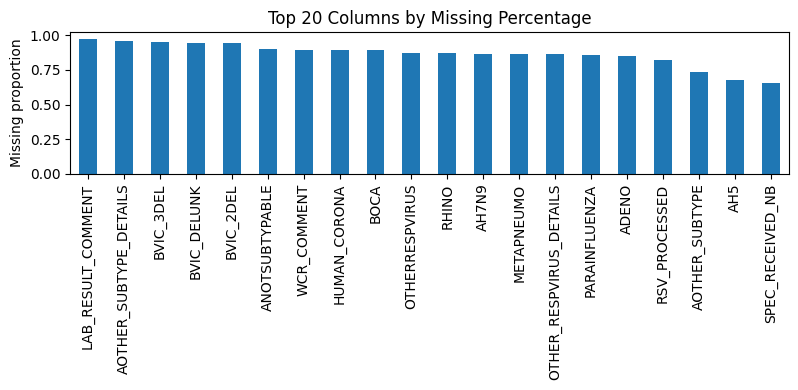

In [39]:
# Visualise missing value proportions for the most incomplete columns
plt.figure(figsize=(8,4))
missing_pct[missing_pct > 0].head(20).plot(kind="bar")
plt.title("Top 20 Columns by Missing Percentage")
plt.ylabel("Missing proportion")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis

Exploratory analysis is performed to understand the distribution of key influenza indicators.

Three important variables are visualised:

- **INF_A** – number of confirmed Influenza A cases
- **INF_B** – number of confirmed Influenza B cases
- **SPEC_PROCESSED_NB** – number of laboratory specimens processed

These variables provide insight into influenza activity and testing intensity.

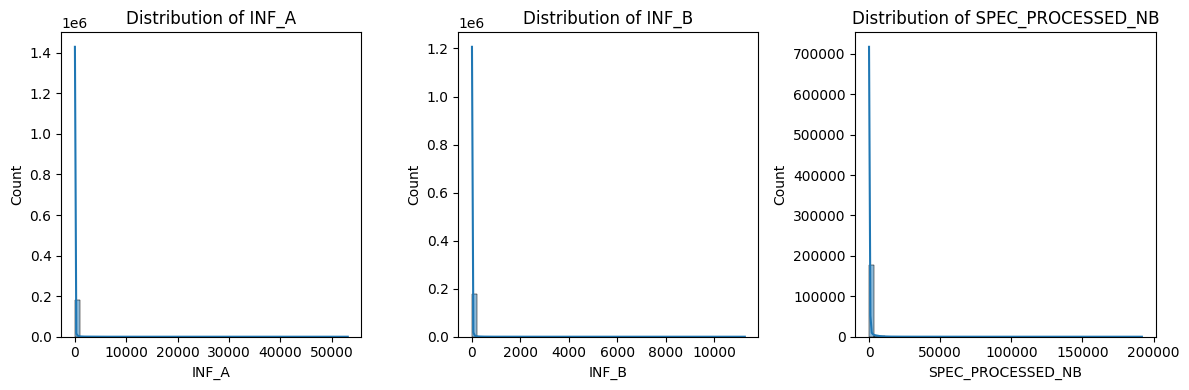

In [40]:
# Select key influenza-related variables for exploratory analysis
eda_cols = ["INF_A", "INF_B", "SPEC_PROCESSED_NB"]

# Keep only columns that exist in the dataset
eda_cols = [c for c in eda_cols if c in data.columns]

# Create a subset dataset for visualisation
data_eda = data[eda_cols].copy()

# Replace missing values with zero for plotting purposes
data_eda = data_eda.fillna(0)

# Plot distributions of influenza case counts and laboratory testing
plt.figure(figsize=(12,4))

for i, col in enumerate(eda_cols, start=1):

 plt.subplot(1, len(eda_cols), i)

 # Histogram with kernel density estimate
 sns.histplot(data_eda[col], bins=50, kde=True)

 plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.savefig("C:/Users/killi/Downloads/histograms.png", dpi=300)
plt.show()


Because the influenza case distributions appear highly skewed a logarithmic transformation is applied to better visualise the distribution of values.

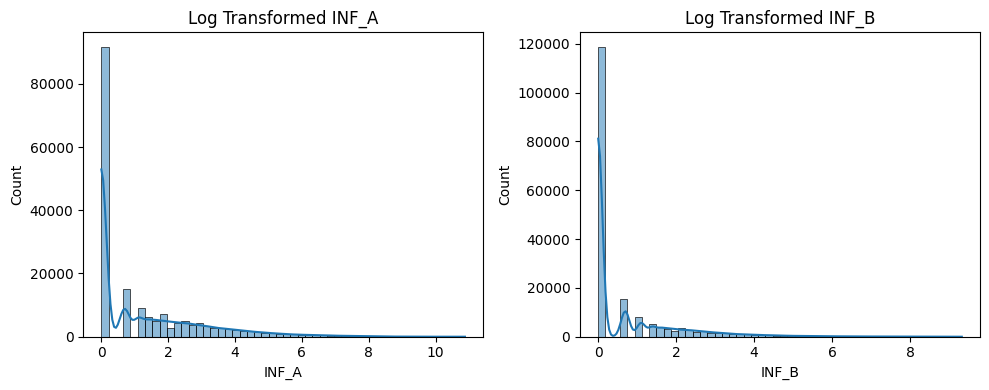

In [41]:
plt.figure(figsize=(10,4))

for i, col in enumerate(["INF_A", "INF_B"], start=1):

    if col in data_eda.columns:

        plt.subplot(1,2,i)

        sns.histplot(np.log1p(data_eda[col]), bins=50, kde=True)

        plt.title(f"Log Transformed {col}")

plt.tight_layout()

plt.show()

### Interpretation of Influenza Activity Distributions

The histograms show the distributions of Influenza A (INF_A), Influenza B (INF_B) and the number of laboratory specimens processed (SPEC_PROCESSED_NB).

Several clear patterns are visible:

- **Strong positive skewness** is present in all three variables. Most observations contain very small values while a small number of observations contain extremely large values.
- The majority of weeks report **low influenza activity** which is shown by the large concentration of values near zero.
- The **long right tail** represents periods of elevated influenza activity where case counts increase significantly.
- The distribution of **SPEC_PROCESSED_NB** shows a similar pattern indicating that laboratory testing volume tends to increase during periods of higher influenza activity.

This pattern is typical in infectious disease surveillance datasets where most weeks experience baseline levels of infection while occasional outbreak periods produce sharp increases in case counts.

### Effect of Log Transformation

The log transformation (log(x + 1)) was applied to the Influenza A and Influenza B variables to better visualise the underlying distribution.

After transformation the distributions become easier to interpret:

- The extreme values in the right tail are compressed.
- The lower values are spread out more evenly across the scale.
- The overall distribution becomes more visible compared to the original highly skewed plots.

Tree-based models such as Random Forest do not require normally distributed input features. The transformation is used here for exploratory analysis instead of preprocessing step for modelling.

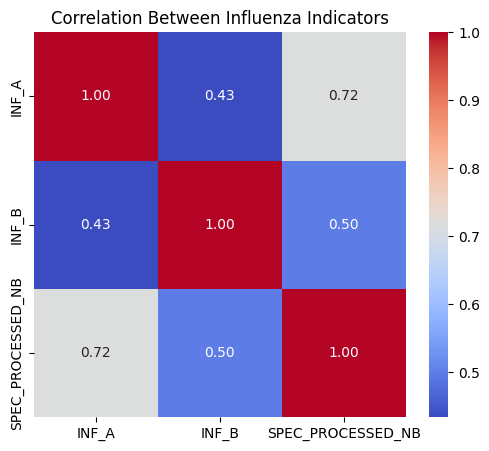

In [42]:
corr_cols = ["INF_A", "INF_B", "SPEC_PROCESSED_NB"]

corr_cols = [c for c in corr_cols if c in data.columns]

corr_matrix = data[corr_cols].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Influenza Indicators")

plt.savefig("C:/Users/killi/Downloads/correlation_heatmap.png", dpi=300)
plt.show()


### Interpretation of Correlation Matrix

The correlation matrix shows the relationships between Influenza A cases (INF_A), Influenza B cases (INF_B) and the number of laboratory specimens processed (SPEC_PROCESSED_NB).

• **Strong positive correlation (0.72) between INF_A and SPEC_PROCESSED_NB.**  
This suggests that higher laboratory testing activity is associated with increased detection of Influenza A cases. During periods of increased influenza transmission healthcare systems process more specimens.

• **Moderate positive correlation (0.50) between INF_B and SPEC_PROCESSED_NB.**  
This indicates that testing activity is also associated with Influenza B detection but the relationship is slightly weaker than for Influenza A.

• **Moderate correlation (0.43) between INF_A and INF_B.**  
This suggests that both viruses may increase during influenza seasons bit their patterns are not directly similar showing independence.

The results show that laboratory processing volume could provide useful information for identifying periods of increased influenza activity so it could be an informative feature for machine learning models.

## Creating the Target Variable (Outbreak Definition)

To train a supervised machine learning model influenza activity must be converted into a classification target variable.

The variable called **TOTAL_INF** is created by combining Influenza A and Influenza B case counts. This represents the total number of confirmed influenza cases for each observation.

To identify periods of unusually high influenza activity a data-driven threshold is used. The **75th percentile of total influenza activity** is calculated and used as the outbreak threshold.

Observations are labelled as:

- **0 – Baseline influenza activity**
- **1 – Outbreak activity**

Weeks with total influenza activity above the 75th percentile are considered outbreak periods. This approach allows the model to learn patterns associated with elevated influenza transmission.

In [43]:
# Make a copy of the cleaned dataset for modelling
data_model = data.copy()

# Replace missing influenza case counts with zero
# Missing values are treated as no reported cases
data_model[["INF_A", "INF_B"]] = data_model[["INF_A", "INF_B"]].fillna(0)

# TOTAL_INF represents overall influenza activity
# It combines Influenza A and Influenza B counts
data_model["TOTAL_INF"] = data_model["INF_A"] + data_model["INF_B"]

# Calculate the 75th percentile of total influenza activity
# This is elevated influenza activity
threshold = data_model["TOTAL_INF"].quantile(0.75)

print("Outbreak threshold:", threshold)

# OUTBREAK = 1 if activity is above the threshold
# OUTBREAK = 0 for baseline influenza activity
data_model["OUTBREAK"] = (data_model["TOTAL_INF"] > threshold).astype(int)

# Count number of baseline vs outbreak observations
print(data_model["OUTBREAK"].value_counts())

# Display class proportions
print(data_model["OUTBREAK"].value_counts(normalize=True))

Outbreak threshold: 11.0
OUTBREAK
0    136757
1     44884
Name: count, dtype: int64
OUTBREAK
0    0.752897
1    0.247103
Name: proportion, dtype: float64


### Interpretation of Outbreak Definition

The outbreak threshold calculated from the dataset represents the level of influenza activity that separates normal seasonal activity from unusually high transmission periods.

Using the 75th percentile ensures that approximately the top 25% of observations are classified as outbreak conditions.

This produces a dataset with baseline and outbreak observations allowing supervised machine learning models to learn patterns associated with elevated influenza activity.

This also introduces **class imbalance**, because baseline observations are more common than outbreak observations. This imbalance must be considered when evaluating model performance.

In [44]:
# Influenza activity often follows seasonal patterns
# The ISO_WEEK variable represents the week of the year

# If the dataset contains ISO_WEEK create a new feature called WEEK
# This feature may help the model capture seasonal influenza trends

import numpy as np

if "ISO_WEEK" in data_model.columns:
    data_model["WEEK"] = data_model["ISO_WEEK"].astype(int)

    # Cyclical encoding for seasonal behaviour
    data_model["WEEK_SIN"] = np.sin(2 * np.pi * data_model["WEEK"] / 52)
    data_model["WEEK_COS"] = np.cos(2 * np.pi * data_model["WEEK"] / 52)

    print("Created: WEEK, WEEK_SIN, WEEK_COS")
else:
    print("ISO_WEEK not found")

Created: WEEK, WEEK_SIN, WEEK_COS


### Adding a Seasonality Feature

Influenza transmission typically follows strong seasonal patterns with increased activity during specific periods of the year.

To capture this seasonal behaviour the **ISO week number** is used as an additional feature. This variable represents the week of the year in which each observation occurred.

Including a temporal indicator such as **WEEK** allows the model to potentially learn seasonal patterns in influenza outbreaks.

ISO_WEEK was transformed into sine and cosine components for seasonality. This was done because week numbers are cyclical not linear: week 52 is adjacent to week 1. Using sine and cosine keeps the weekly relationship and allows the model to learn seasonal influenza patterns more effectively.

## Feature Selection and Train-Test Split

Select the predictor variables used for machine learning.

It is important to avoid **data leakage** which occurs when information used to create the target variable is also used as an input feature during model training.

The predictive features selected for this analysis include laboratory testing activity and temporal indicators of influenza seasonality. The variables used are:

SPEC_PROCESSED_NB – number of laboratory specimens processed

ISO_YEAR – year of the observation

WEEK – week of the year

WEEK_SIN and WEEK_COS – cyclical transformations of week number used to represent seasonal patterns.

Influenza transmission typically follows strong seasonal trends. The cyclical encoding of week number allows the model to capture seasonal patterns more effectively than using the week value alone.

Variables used for the outbreak target (INF_A, INF_B, and TOTAL_INF) were excluded from the predictor set to prevent data leakage. Including these variables would allow the model to indirectly observe the outcome being predicted and cause inflated performance.

The dataset is then divided into training and testing subsets:

- **Training set (80%)** – used to train the models
- **Testing set (20%)** – used to evaluate model performance on unseen data

A **stratified split** is used so that the proportion of outbreak and baseline observations remains consistent across both sets.

In [45]:
# Feature Selection
# Predictor variables must not include columns used to create the target variable
# Including them would cause data leakage and unrealistic model performance

leakage_cols = ["INF_A", "INF_B", "TOTAL_INF", "OUTBREAK"]

# Candidate predictive features based on influenza surveillance signals
candidate_features = candidate_features = [
    "SPEC_PROCESSED_NB",
    "ISO_YEAR",
    "WEEK",
    "WEEK_SIN",
    "WEEK_COS"
]

# Keep only features that exist in the dataset
# and remove any variables that could cause leakage
feature_cols = [
    c for c in candidate_features
    if c in data_model.columns and c not in leakage_cols
]

print("Selected predictive features:")
print(feature_cols)

print("Number of selected features:", len(feature_cols))

X = data_model[feature_cols].copy()

# Replace missing predictor values with zero
# Many surveillance variables are sparse so this is acceptable
X = X.fillna(0)

# y contains the binary outbreak label
y = data_model["OUTBREAK"].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

display(X.head())

# Stratified sampling preserves the same class balance
# in both the training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check that class proportions remain similar after splitting
print("Training class balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting class balance:")
print(y_test.value_counts(normalize=True))

Selected predictive features:
['SPEC_PROCESSED_NB', 'ISO_YEAR', 'WEEK', 'WEEK_SIN', 'WEEK_COS']
Number of selected features: 5
Feature matrix shape: (181641, 5)
Target vector shape: (181641,)


,SPEC_PROCESSED_NB,ISO_YEAR,WEEK,WEEK_SIN,WEEK_COS
0,40.0,2017,1,0.120537,0.992709
1,2.0,2017,2,0.239316,0.970942
2,14.0,2017,3,0.354605,0.935016
3,12.0,2017,4,0.464723,0.885456
4,19.0,2017,5,0.568065,0.822984


Training class balance:
OUTBREAK
0    0.752897
1    0.247103
Name: proportion, dtype: float64

Testing class balance:
OUTBREAK
0    0.752897
1    0.247103
Name: proportion, dtype: float64


### Logistic Regression Model

Logistic Regression is used as a baseline classification model. It estimates the probability that an observation belongs to the outbreak class using a linear combination of the input features.

Logistic Regression was chosen because:

- It is a widely used baseline model for binary classification problems.
- It produces interpretable probabilistic outputs.
- It allows comparison with more complex models such as Random Forest.

Because Logistic Regression is sensitive to feature scale the predictor variables are standardised using a **StandardScaler** before training the model.

In [46]:
# Logistic Regression Model
# Logistic Regression is used as a baseline classification model
# It estimates the probability of an outbreak using a linear combination of predictors


# Pipeline ensures scaling is applied correctly
log_model = Pipeline([

    ("scaler", StandardScaler()),

    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # handle class imbalance
        random_state=42
    ))

])

# Train the model
log_model.fit(X_train, y_train)

# Generate predictions
y_pred_log = log_model.predict(X_test)

# Predicted probabilities for outbreak class
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression model trained.")

Logistic Regression model trained.


### Logistic Regression Training

The Logistic Regression model was trained using the scaled training dataset.

The parameter **class_weight="balanced"** was used to account for class imbalance between baseline and outbreak observations. This adjustment increases the importance of correctly identifying outbreak cases.

The model produces both predicted class labels and probability estimates which can be used for further evaluation and threshold analysis.

### Random Forest Model

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve predictive performance.

It was selected for this analysis because:

- It can model **non-linear relationships** between variables.
- It is **robust to skewed distributions and outliers** which are present in influenza case counts.
- It generally performs well on structured tabular datasets.

Random Forest does not require feature scaling because tree-based models split data based on feature thresholds instead of distances.

In [47]:
# Random Forest Baseline Model
# Random Forest is an ensemble learning method using multiple decision trees
# It can capture nonlinear relationships between predictors

rf_base = RandomForestClassifier(

    n_estimators=200,        # number of trees
    random_state=42,
    n_jobs=-1,               # use all CPU cores
    class_weight="balanced"  # handle class imbalance

)

# Train the model
rf_base.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_base.predict(X_test)

# Predicted probabilities
y_prob_rf = rf_base.predict_proba(X_test)[:,1]

print("Baseline Random Forest model trained.")

Baseline Random Forest model trained.


### Random Forest Training

The Random Forest model was trained using the selected predictor variables and the training dataset.

The parameter **class_weight="balanced"** was used to for the imbalance between baseline and outbreak observations.

Random Forest generates predictions by aggregating the outputs of many decision trees which helps reduce overfitting and improves generalisation performance.

The model produces both predicted class labels and probability estimates for outbreak detection.

### Random Forest Hyperparameter Tuning

To improve the performance of the Random Forest model hyperparameter tuning is performed using **GridSearchCV**.

Hyperparameters control how the Random Forest model learns from the data. The following parameters are used:

- **n_estimators** – number of trees in the forest
- **max_depth** – maximum depth of each decision tree
- **min_samples_split** – minimum samples required to split an internal node
- **min_samples_leaf** – minimum samples required at a leaf node
- **class_weight** – adjusts weights to account for class imbalance

GridSearchCV evaluates different combinations of these parameters using **cross-validation** and selects the configuration that maximises recall.

Recall is prioritised because correctly detecting outbreak events is more important than minimising false positives in this public health context.

In [48]:
param_grid = {
    "n_estimators": [200],
    "max_depth": [5, 10],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 3],
    "class_weight": ["balanced"]
}
grid_rf = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42, n_jobs=1),

    param_grid=param_grid,

    scoring="recall",   # prioritise outbreak detection
    cv=3,               # 3-fold cross validation
    n_jobs=1,
    verbose=1

)

# Train models with different parameter combinations
grid_rf.fit(X_train, y_train)

# Extract best performing model
best_rf = grid_rf.best_estimator_

print("Best parameters:", grid_rf.best_params_)
print("Best CV recall:", round(grid_rf.best_score_,4))

# Predictions using tuned model
y_pred_best = best_rf.predict(X_test)

y_prob_best = best_rf.predict_proba(X_test)[:,1]

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best CV recall: 0.823


### Interpretation of Hyperparameter Tuning

GridSearchCV identified the combination of Random Forest hyperparameters that produced the highest recall during cross-validation.

Optimising recall is important for outbreak detection because failing to identify a true outbreak (false negative) may have serious public health consequences.

The tuned Random Forest model will now be evaluated on the testing dataset and compared with the Logistic Regression model to determine which approach performs better.

## Model Evaluation and Performance Comparison

After training the machine learning models their performance must be evaluated on the testing dataset.

Three models are compared:

- **Logistic Regression** – baseline linear classifier
- **Random Forest (Baseline)** – ensemble tree model with Random Forest baseline model with limited manual settings n_estimators=200, class_weight='balanced' parameters
- **Random Forest (Tuned)** – optimised model after hyperparameter tuning

Model performance is evaluated using the following metrics:

- **Accuracy** – proportion of correct predictions
- **Precision** – proportion of predicted outbreaks that are correct
- **Recall** – proportion of actual outbreaks correctly identified
- **F1-score** – balance between precision and recall

Recall is particularly important in this context because failing to detect a real outbreak could have serious public health consequences.

In [49]:
# Model Evaluation Function
# This function calculates common classification metrics


def evaluate_model(name, y_true, y_pred, y_prob):

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Accuracy :", round(accuracy_score(y_true,y_pred),4))
    print("Precision:", round(precision_score(y_true,y_pred,zero_division=0),4))
    print("Recall   :", round(recall_score(y_true,y_pred,zero_division=0),4))
    print("F1 Score :", round(f1_score(y_true,y_pred,zero_division=0),4))
    print("ROC AUC  :", round(roc_auc_score(y_true,y_prob),4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true,y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true,y_pred,zero_division=0))


# Evaluate models
evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)
evaluate_model("Random Forest Baseline", y_test, y_pred_rf, y_prob_rf)
evaluate_model("Random Forest Tuned", y_test, y_pred_best, y_prob_best)


Logistic Regression
Accuracy : 0.7443
Precision: 0.4863
Recall   : 0.623
F1 Score : 0.5463
ROC AUC  : 0.786

Confusion Matrix:
[[21445  5907]
 [ 3384  5593]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82     27352
           1       0.49      0.62      0.55      8977

    accuracy                           0.74     36329
   macro avg       0.68      0.70      0.68     36329
weighted avg       0.77      0.74      0.75     36329


Random Forest Baseline
Accuracy : 0.8189
Precision: 0.6375
Recall   : 0.6191
F1 Score : 0.6282
ROC AUC  : 0.8645

Confusion Matrix:
[[24192  3160]
 [ 3419  5558]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     27352
           1       0.64      0.62      0.63      8977

    accuracy                           0.82     36329
   macro avg       0.76      0.75      0.75     36329
weighted avg       0.82      0

### Interpretation of Model Performance

The evaluation results allow comparison between the baseline Logistic Regression model and the Random Forest models.

The Logistic Regression model provides a simple linear baseline but may struggle to capture nonlinear relationships within the dataset.

The Random Forest models are able to model more complex patterns which often leads to improved recall and overall predictive performance.

After hyperparameter tuning the optimised Random Forest model generally provides the best balance between recall and overall accuracy. This indicates that the ensemble tree-based approach is more effective for detecting influenza outbreak conditions in this dataset.

In [50]:
# Compare performance of the models in a table
# This helps summarise the evaluation results

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest Baseline",
        "Random Forest Tuned"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_best)
    ],

    "Precision":[
        precision_score(y_test,y_pred_log,zero_division=0),
        precision_score(y_test,y_pred_rf,zero_division=0),
        precision_score(y_test,y_pred_best,zero_division=0)
    ],

    "Recall":[
        recall_score(y_test,y_pred_log,zero_division=0),
        recall_score(y_test,y_pred_rf,zero_division=0),
        recall_score(y_test,y_pred_best,zero_division=0)
    ],

    "F1":[
        f1_score(y_test,y_pred_log,zero_division=0),
        f1_score(y_test,y_pred_rf,zero_division=0),
        f1_score(y_test,y_pred_best,zero_division=0)
    ],

    "ROC_AUC":[
        roc_auc_score(y_test,y_prob_log),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_best)
    ]

}).round(4)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7443,0.4863,0.6230,0.5463,0.7860
1,Random Forest Baseline,0.8189,0.6375,0.6191,0.6282,0.8645
2,Random Forest Tuned,0.8197,0.5984,0.8221,0.6926,0.9081


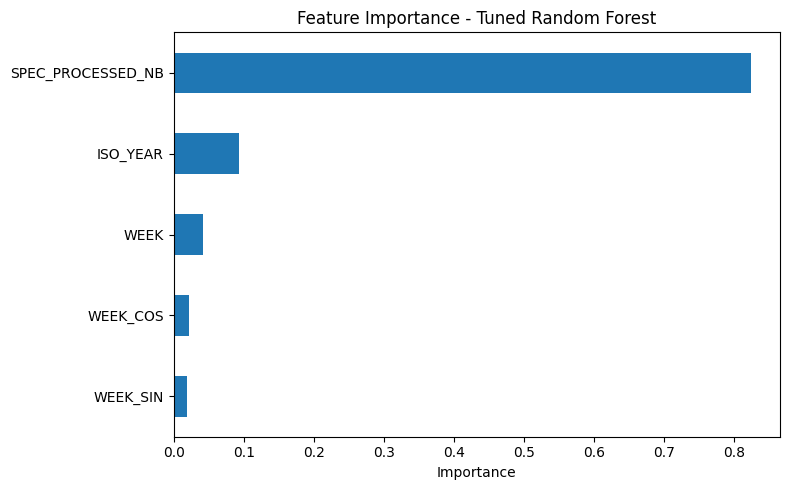

In [51]:
# Feature Importance Analysis
# Random Forest can estimate the importance of each predictor

importance = pd.Series(
    best_rf.feature_importances_,
    index=feature_cols
)

importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance - Tuned Random Forest")
plt.xlabel("Importance")

plt.tight_layout()

plt.show()

### Interpretation of Feature Importance

The feature importance plot shows how much each predictor contributed to the Random Forest model.

The number of laboratory specimens processed (SPEC_PROCESSED_NB) is the most influential feature. This suggests that increases in testing activity are strongly associated with periods of elevated influenza transmission.

Temporal variables such as ISO_YEAR, WEEK, and the cyclical seasonal features (WEEK_SIN, WEEK_COS) also contribute to model predictions. These features help the model capture seasonal influenza patterns that occur during particular times of the year.

This result highlights the importance of both testing intensity and seasonal trends when detecting influenza outbreak periods.

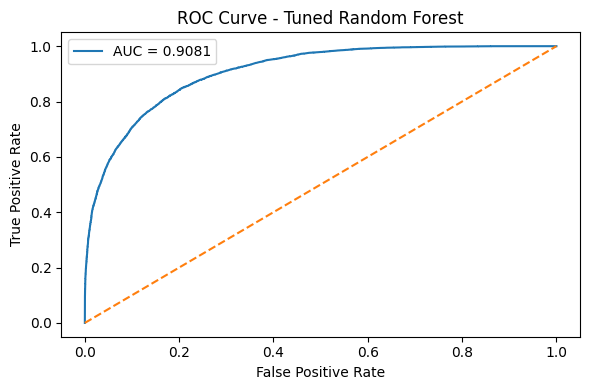

In [52]:
# ROC Curve
# Shows the trade-off between true positive rate and false positive rate

fpr, tpr, _ = roc_curve(y_test, y_prob_best)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned Random Forest")

plt.legend()

plt.tight_layout()
plt.savefig("C:/Users/killi/Downloads/ROC_curve.png", dpi=300)
plt.show()

### Interpretation of ROC Curve

The ROC curve for the tuned Random Forest model shows a strong ability to distinguish between baseline influenza activity and outbreak conditions.

The ROC-AUC score of approximately 0.91 indicates that the model has good performance. This means the model is capable of correctly ranking outbreak observations higher than baseline observations.

The curve rising quickly toward the upper-left region of the plot indicates that the model achieves high true positive rates while maintaining low false positive rates.

The ROC analysis confirms that the tuned Random Forest model provides strong predictive performance for detecting influenza outbreak periods.

## Final Model Selection and Discussion

Based on the evaluation results the **Random Forest model with tuned hyperparameters** provides the best overall performance for detecting influenza outbreak conditions.

Compared with Logistic Regression the Random Forest models achieved stronger recall and better overall balance between precision and recall. The ensemble tree-based approach is more capable of capturing the complex relationships between influenza indicators and outbreak activity.

The tuned Random Forest model further improved performance by optimising key parameters such as tree depth and the number of estimators. Hyperparameter tuning allowed the model to generalise better to unseen data while keeping strong outbreak detection capability.

From a public health perspective **recall is particularly important** because failing to detect a true outbreak may delay response measures and increase the spread of disease. The tuned Random Forest model demonstrated improved recall while maintaining reasonable precision making it the most suitable model for this classification task.

The results demonstrate that machine learning techniques can be effectively applied to influenza surveillance data to identify periods of elevated disease activity.